### Load TF-IDF Feature Matrices and Labels

In this step, we load the precomputed TF-IDF feature matrices for the training

In [ ]:
# Load TF-IDF Data

import numpy as np
from scipy.sparse import load_npz

# Load TF-IDF feature matrices
X_train = load_npz("X_train_tfidf.npz")
X_val = load_npz("X_val_tfidf.npz")
X_test = load_npz("X_test_tfidf.npz")

y_train = np.load("y_train.npy")
y_val = np.load("y_val.npy")
y_test = np.load("y_test.npy")

# Print dataset shapes to verify correctness
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (75000, 20000) (75000,)
Validation: (44767, 20000) (44767,)
Test: (89535, 20000) (89535,)


### Import Logistic Regression and Evaluation Metrics

In this step, we import the Logistic Regression model along with the necessary evaluation metrics. These metrics will be used to assess the performance of the model on the validation and test sets.

The evaluation includes Accuracy, Precision, Recall, and F1-score, which provide a comprehensive understanding of model performance, especially for imbalanced datasets. Additionally, we import tools for generating a classification report and confusion matrix for detailed analysis.

In [ ]:
# Import Logistic Regression And Evaluation Metrics

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics for model performance
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

### Hyperparameter Tuning for Logistic Regression

In this step, we perform hyperparameter tuning for the Logistic Regression model using different values of the regularization parameter (C).

In [ ]:
# Hyperparameter Tuning

# Different values of regularization strength to test
# Smaller C = stronger regularization, Larger C = weaker regularization
C_values = [0.001, 0.01, 0.1, 1, 10]
results = []

 # Initialize Logistic Regression model
for C in C_values:
    model = LogisticRegression(
        C=C,
        class_weight="balanced",   # Handle class imbalance
        max_iter=3000,           # Ensure convergence
        random_state=42,
        solver="saga",               # Efficient for large datasets
        n_jobs=-1
    )

    # Train model on training data
    model.fit(X_train, y_train)

        # Predict on validation set
    y_val_pred = model.predict(X_val)


    # Store evaluation metrics
    results.append({
        "C": C,
        "macro_f1": f1_score(y_val, y_val_pred, average="macro"),
        "weighted_f1": f1_score(y_val, y_val_pred, average="weighted"),
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision_macro": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, y_val_pred, average="macro", zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

,C,macro_f1,weighted_f1,accuracy,precision_macro,recall_macro
0,0.001,0.473116,0.652872,0.642370,0.456521,0.500824
1,0.010,0.494101,0.665345,0.651015,0.474129,0.525890
2,0.100,0.545313,0.693671,0.674046,0.521647,0.584665
3,1.000,0.592282,0.718152,0.697902,0.567369,0.636527
4,10.000,0.592337,0.706448,0.682914,0.567140,0.645166


The results show that increasing the value of C improves the model performance, as higher values lead to better Macro F1-scores. The best performance was achieved at C = 10, with a Macro F1-score of approximately 0.59.


### Select the Best Hyperparameter (Based on Macro F1-score)

In this step, we select the best hyperparameter value (C) based on the highest Macro F1-score obtained from the validation results.

In [ ]:
# Pick The Best Hyperparameter (based on Macro F1)

# Sort results by Macro F1-score in descending order
# and select the best-performing row
best_row = results_df.sort_values(by="macro_f1", ascending=False).iloc[0]

# Extract the best value of C
best_C = best_row["C"]

print("Best C:", best_C)
print(best_row)

Best C: 10.0
C                  10.000000
macro_f1            0.592337
weighted_f1         0.706448
accuracy            0.682914
precision_macro     0.567140
recall_macro        0.645166
Name: 4, dtype: float64


### Train Final Logistic Regression Model

Train the final model using the best value of C selected from validation.

In [ ]:
# Train The Logistic Regression Model Using The Best Hyperparameter
# Initialize final model with best C
final_model = LogisticRegression(
    C=best_C,
    class_weight="balanced",
    max_iter=3000,
    random_state=42,
    solver="saga",
    n_jobs=-1
)

final_model.fit(X_train, y_train)

LogisticRegression(C=np.float64(10.0), class_weight='balanced', max_iter=3000,
                   n_jobs=-1, random_state=42, solver='saga')

The final Logistic Regression model is trained using the best hyperparameter value (C = 10) selected from the validation step.

This configuration provides the best performance in terms of Macro F1-score, ensuring a balanced prediction across all classes. The use of class_weight="balanced" further helps the model handle class imbalance effectively.

Training the final model with these settings allows it to fully utilize the training data and achieve optimal performance before evaluation on the test set.

### Evaluate on Test Set

Evaluate the final model on the test set using standard metrics.

In [ ]:
# Evaluate On The Test Set

# Predict on test data
y_test_pred = final_model.predict(X_test)

test_metrics = {
    "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
    "weighted_f1": f1_score(y_test, y_test_pred, average="weighted"),
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision_macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0)
}

print(test_metrics)

{'macro_f1': 0.5939365003689769, 'weighted_f1': 0.7068992349723588, 'accuracy': 0.6826157368626794, 'precision_macro': 0.5691519168480659, 'recall_macro': 0.6480104380558227}


The final Logistic Regression model is trained using the selected value of C = 10 from the validation step.

This choice reflects the best observed trade-off during tuning, although the improvement over C = 1 is relatively small. The model still shows limitations, particularly in handling middle classes (e.g., ratings 2–4), which indicates that the problem remains challenging despite tuning.

Using class_weight="balanced" helps mitigate class imbalance, but it does not fully solve it. Overall, this configuration is selected as the most reasonable option based on validation results, rather than a clearly superior model.

### Classification Report

In this step, we generate a detailed classification report to evaluate the performance of the model on each class individually.

The report includes Precision, Recall, and F1-score for each class, in addition to the overall Accuracy and the Macro and Weighted averages.

In [ ]:
print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.71      0.73      0.72      8839
           2       0.41      0.61      0.49      4923
           3       0.43      0.61      0.51      6973
           4       0.36      0.58      0.45     12680
           5       0.93      0.71      0.81     56120

    accuracy                           0.68     89535
   macro avg       0.57      0.65      0.59     89535
weighted avg       0.76      0.68      0.71     89535




The classification report shows that the model performs unevenly across classes. It achieves relatively strong performance on class 1 and especially class 5, which is expected since class 5 has the largest number of samples.

However, the performance on classes 2, 3, and 4 is noticeably weaker, with lower precision and F1-scores. This suggests that the model struggles to distinguish between middle rating levels, likely due to overlapping sentiment in the text.

The Macro F1-score (0.59) indicates moderate overall performance across all classes, while the higher Weighted F1-score (~0.71) reflects the model’s bias toward the majority class. Overall, the model captures general sentiment trends but lacks fine-grained discrimination between similar classes.

### Confusion Matrix

In this step, we visualize the confusion matrix to analyze the model’s predictions in more detail.

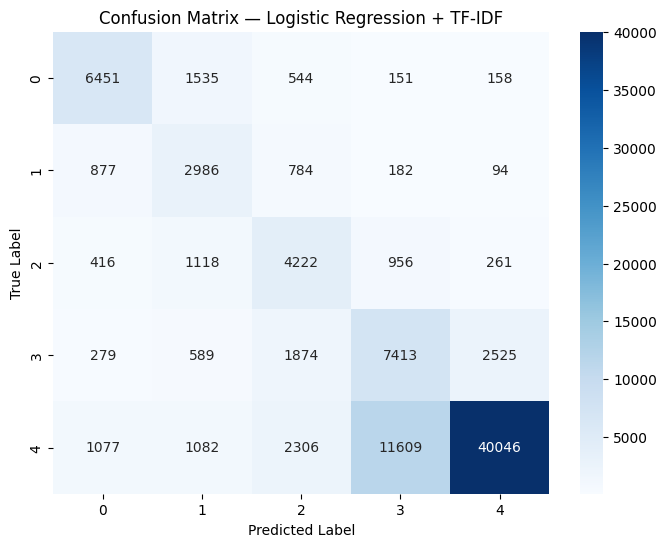

In [ ]:
# Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression + TF-IDF")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


The confusion matrix shows that the model performs well on extreme classes (1 and 5), where most predictions are concentrated on the diagonal, especially for class 5 which has the largest number of samples.

However, there is significant confusion between the middle classes (2, 3, and 4). Many samples from these classes are misclassified into neighboring classes, particularly class 4 being predicted as class 5, and class 3 being confused with both 2 and 4.

This pattern suggests that the model struggles to capture fine-grained differences in sentiment, and instead tends to group similar ratings together. Overall, the model captures general sentiment direction but lacks precision when distinguishing between close rating levels.

 Validation Tuning Results


In [ ]:
# Validation Tuning Results

results_df.to_csv("results_lr_tfidf_validation.csv", index=False)

# Final Test Result


In [ ]:
# Final Test Result

final_results_df = pd.DataFrame([{
    "model": "Logistic Regression",
    "features": "TF-IDF",
    "best_C": best_C,
    "macro_f1": test_metrics["macro_f1"],
    "weighted_f1": test_metrics["weighted_f1"],
    "accuracy": test_metrics["accuracy"],
    "precision_macro": test_metrics["precision_macro"],
    "recall_macro": test_metrics["recall_macro"]
}])

final_results_df.to_csv("results_lr_tfidf_test.csv", index=False)
final_results_df

,model,features,best_C,macro_f1,weighted_f1,accuracy,precision_macro,recall_macro
0,Logistic Regression,TF-IDF,10.0,0.593937,0.706899,0.682616,0.569152,0.64801



The final results show that the model achieves a Macro F1-score of around 0.59 and an accuracy of approximately 0.68.

The gap between Macro F1 and Weighted F1 (~0.71) indicates that the model is biased toward the majority class (rating 5). While overall accuracy is acceptable, the Macro F1 reveals that performance across classes is only moderate.

These results confirm that the model captures general sentiment trends but struggles with fine-grained classification, especially for middle rating levels.